# Taller de Tesis I — Entrega 1
## Dataset, Pregunta de Investigación y Objetivo

**Maestría en Data Mining — FCEyN, UBA**  
**Grupo:** G2  
**Alumno:** [Tu nombre]  
**Dataset:** Stack Overflow Developer Survey 2023 + 2024 + 2025

## 0. Configuración e imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 60)
sns.set_theme(style='darkgrid', palette='muted')

print('✅ Imports OK')

✅ Imports OK


## 1. Carga de datos

Descargá los CSVs desde https://survey.stackoverflow.co/ y colocálos en `../data/`

**Diferencias de schema a tener en cuenta:**
- `AISelect`: en 2025 los valores de uso se granularizaron en frecuencia (`daily/weekly/monthly`) → se normalizan a `'Yes'`
- `YearsCodePro`: no existe en 2025 (reemplazado por `YearsCode` a secas)
- `AISent`: consistente en los tres años (Favorable / Very favorable / etc.)

In [2]:
df23 = pd.read_csv('../data/survey_results_public_2023.csv', low_memory=False)
df24 = pd.read_csv('../data/survey_results_public_2024.csv', low_memory=False)
df25 = pd.read_csv('../data/survey_results_public_2025.csv', low_memory=False)

df23['survey_year'] = 2023
df24['survey_year'] = 2024
df25['survey_year'] = 2025

# --- Normalización de schemas ---

# 2025: AISelect usa valores granulares de frecuencia → normalizar a 'Yes'
aiselect_yes_2025 = [
    'Yes, I use AI tools daily',
    'Yes, I use AI tools weekly',
    'Yes, I use AI tools monthly or infrequently',
]
df25['AISelect'] = df25['AISelect'].apply(
    lambda v: 'Yes' if v in aiselect_yes_2025 else v
)

# 2025: YearsCodePro no existe; renombrar YearsCode a YearsCodePro para unificar
# (2023 y 2024 tienen ambas columnas, en 2025 solo existe YearsCode)
if 'YearsCodePro' not in df25.columns and 'YearsCode' in df25.columns:
    df25['YearsCodePro'] = df25['YearsCode']

print(f'2023: {df23.shape[0]:,} filas, {df23.shape[1]} columnas')
print(f'2024: {df24.shape[0]:,} filas, {df24.shape[1]} columnas')
print(f'2025: {df25.shape[0]:,} filas, {df25.shape[1]} columnas')
print(f'Total acumulado: {df23.shape[0] + df24.shape[0] + df25.shape[0]:,} filas')

2023: 89,184 filas, 85 columnas
2024: 65,437 filas, 115 columnas
2025: 49,191 filas, 174 columnas
Total acumulado: 203,812 filas


## 2. Detección de columnas de IA

In [3]:
ai_cols_23 = [c for c in df23.columns if 'AI' in c]
ai_cols_24 = [c for c in df24.columns if 'AI' in c]
ai_cols_25 = [c for c in df25.columns if 'AI' in c]

print('=== Columnas de IA en 2023 ===')
print(ai_cols_23)
print('\n=== Columnas de IA en 2024 ===')
print(ai_cols_24)
print('\n=== Columnas de IA en 2025 ===')
print(ai_cols_25)

=== Columnas de IA en 2023 ===
['AISearchHaveWorkedWith', 'AISearchWantToWorkWith', 'AIDevHaveWorkedWith', 'AIDevWantToWorkWith', 'SOAI', 'AISelect', 'AISent', 'AIAcc', 'AIBen', 'AIToolInterested in Using', 'AIToolCurrently Using', 'AIToolNot interested in Using', 'AINextVery different', 'AINextNeither different nor similar', 'AINextSomewhat similar', 'AINextVery similar', 'AINextSomewhat different']

=== Columnas de IA en 2024 ===
['AISearchDevHaveWorkedWith', 'AISearchDevWantToWorkWith', 'AISearchDevAdmired', 'AISelect', 'AISent', 'AIBen', 'AIAcc', 'AIComplex', 'AIToolCurrently Using', 'AIToolInterested in Using', 'AIToolNot interested in Using', 'AINextMuch more integrated', 'AINextNo change', 'AINextMore integrated', 'AINextLess integrated', 'AINextMuch less integrated', 'AIThreat', 'AIEthics', 'AIChallenges']

=== Columnas de IA en 2025 ===
['LearnCodeAI', 'AILearnHow', 'AIThreat', 'AIModelsChoice', 'AIModelsHaveWorkedWith', 'AIModelsWantToWorkWith', 'AIModelsAdmired', 'AIModelsHa

## 3. Exploración de valores en columnas clave

Verificamos los valores reales de las columnas que definen el target.

`AISent` es la columna de **actitud/favorable stance** y es consistente en los tres años.  
`AISelect` ya fue normalizado en la celda anterior.

In [4]:
for col in ['AISelect', 'AISent']:
    for year, df in [(2023, df23), (2024, df24), (2025, df25)]:
        if col in df.columns:
            print(f'\n--- {col} ({year}) ---')
            print(df[col].value_counts(dropna=False))


--- AISelect (2023) ---
AISelect
Yes                        39042
No, and I don't plan to    26221
No, but I plan to soon     22710
NaN                         1211
Name: count, dtype: int64

--- AISelect (2024) ---
AISelect
Yes                        37662
No, and I don't plan to    14837
No, but I plan to soon      8408
NaN                         4530
Name: count, dtype: int64

--- AISelect (2025) ---
AISelect
Yes                        26469
NaN                        15471
No, and I don't plan to     5454
No, but I plan to soon      1797
Name: count, dtype: int64

--- AISent (2023) ---
AISent
Favorable           29863
NaN                 27683
Very favorable      17050
Indifferent         10147
Unsure               2471
Unfavorable          1698
Very unfavorable      272
Name: count, dtype: int64

--- AISent (2024) ---
AISent
Favorable           22167
NaN                 19564
Very favorable      10848
Indifferent          8564
Unfavorable          2381
Unsure               1357


In [5]:
# Verificación de consistencia de AISent entre años
# Importante: la tasa de adopción baja de 44% (2024) a 38% (2025).
# Necesitamos confirmar que los labels de AISent son comparables.
print("=== Valores únicos de AISent por año ===")
for year, df_year in [(2023, df23), (2024, df24), (2025, df25)]:
    vals = df_year['AISent'].dropna().unique().tolist()
    print(f"\n{year}: {sorted(vals)}")

# Verificar que 'Favorable' y 'Very favorable' existen en los 3 años
expected = {'Favorable', 'Very favorable'}
for year, df_year in [(2023, df23), (2024, df24), (2025, df25)]:
    found = set(df_year['AISent'].dropna().unique())
    missing_vals = expected - found
    if missing_vals:
        print(f"\n⚠️  {year}: valores faltantes en AISent: {missing_vals}")
        print("   → Revisar mapeo antes de construir el target")
    else:
        print(f"\n✅ {year}: AISent tiene los valores esperados para el target")

=== Valores únicos de AISent por año ===

2023: ['Favorable', 'Indifferent', 'Unfavorable', 'Unsure', 'Very favorable', 'Very unfavorable']

2024: ['Favorable', 'Indifferent', 'Unfavorable', 'Unsure', 'Very favorable', 'Very unfavorable']

2025: ['Favorable', 'Indifferent', 'Unfavorable', 'Unsure', 'Very favorable', 'Very unfavorable']

✅ 2023: AISent tiene los valores esperados para el target

✅ 2024: AISent tiene los valores esperados para el target

✅ 2025: AISent tiene los valores esperados para el target


## 4. Alineación y unificación de datasets

In [6]:
cols_perfil = [
    'Country', 'DevType', 'YearsCodePro', 'OrgSize',
    'EdLevel', 'Employment', 'LanguageHaveWorkedWith',
    'CompTotal', 'WorkExp', 'survey_year'
]
cols_ia = ['AISelect', 'AISent', 'AIAcc', 'AIBen']

# Corrección: en 2023, AIAcc y AIBen tienen significados invertidos respecto a 2024+
# AIAcc 2023 = beneficios esperados (multi-select) → renombrar a AIBen
# AIBen 2023 = nivel de confianza → renombrar a AIAcc
df23 = df23.rename(columns={'AIAcc': 'AIBen', 'AIBen': 'AIAcc'})
print("✅ Renombramiento AIAcc↔AIBen en 2023 aplicado")

def filtrar_cols(df, cols):
    return [c for c in cols if c in df.columns]

df23_sub = df23[filtrar_cols(df23, cols_perfil + cols_ia)].copy()
df24_sub = df24[filtrar_cols(df24, cols_perfil + cols_ia)].copy()
df25_sub = df25[filtrar_cols(df25, cols_perfil + cols_ia)].copy()

df = pd.concat([df23_sub, df24_sub, df25_sub], ignore_index=True)
print(f'Dataset unificado: {df.shape[0]:,} filas, {df.shape[1]} columnas')
print(f'Filas por año:\n{df["survey_year"].value_counts().sort_index()}')
df.head(3)

✅ Renombramiento AIAcc↔AIBen en 2023 aplicado
Dataset unificado: 203,812 filas, 14 columnas
Filas por año:
survey_year
2023    89184
2024    65437
2025    49191
Name: count, dtype: int64


,Country,DevType,YearsCodePro,OrgSize,EdLevel,Employment,LanguageHaveWorkedWith,CompTotal,WorkExp,survey_year,AISelect,AISent,AIAcc,AIBen
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023,NaN,NaN,NaN,NaN
1,United States of America,"Senior Executive (C-Suite, VP, etc.)",9,2 to 9 employees,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Employed, full-time",HTML/CSS;JavaScript;Python,285000.0,10.0,2023,Yes,Indifferent,Somewhat distrust,Other (please explain)
2,United States of America,"Developer, back-end",23,"5,000 to 9,999 employees","Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Employed, full-time",Bash/Shell (all shells);Go,250000.0,23.0,2023,"No, and I don't plan to",NaN,NaN,NaN


## 5. Construcción de la variable target

**Criterio:**
- `target = 1` → usa IA actualmente en su trabajo (`AISelect == 'Yes'`) **Y** tiene actitud favorable o muy favorable (`AISent`)
- `target = 0` → cualquier otro caso

**Columnas usadas:**
- `AISelect`: uso actual (normalizado: 2025 granular → `'Yes'`)
- `AISent`: actitud hacia IA — consistente en los 3 años

**Justificación:** captura "adoptante sostenido", no solo quien lo probó. Basado en el Technology Acceptance Model (TAM).

In [7]:
usa_ia = ['Yes']  # normalizado: los valores granulares de 2025 ya fueron mapeados a 'Yes'

actitud_positiva = ['Favorable', 'Very favorable']

df['target'] = (
    df['AISelect'].isin(usa_ia) &
    df['AISent'].isin(actitud_positiva)
).astype(int)

total = len(df)
adoptantes = df['target'].sum()
print(f'Target = 1 (adoptantes):     {adoptantes:,} ({adoptantes/total:.1%})')
print(f'Target = 0 (no adoptantes):  {total-adoptantes:,} ({(total-adoptantes)/total:.1%})')
print()
print('Tasa de adopción por año:')
print((df.groupby('survey_year')['target'].mean() * 100).round(1).astype(str) + '%')

Target = 1 (adoptantes):     80,913 (39.7%)
Target = 0 (no adoptantes):  122,899 (60.3%)

Tasa de adopción por año:
survey_year
2023    37.0%
2024    44.1%
2025    38.7%
Name: target, dtype: str


## 6. Descripción general del dataset

In [8]:
print('=== Tipos de datos ===')
print(df.dtypes)
print(f'\n=== Valores faltantes (%) ===')
missing = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
print(missing[missing > 0].round(1))

=== Tipos de datos ===
Country                       str
DevType                       str
YearsCodePro               object
OrgSize                       str
EdLevel                       str
Employment                    str
LanguageHaveWorkedWith        str
CompTotal                 float64
WorkExp                   float64
survey_year                 int64
AISelect                      str
AISent                        str
AIAcc                         str
AIBen                         str
target                      int64
dtype: object

=== Valores faltantes (%) ===


AIBen                     63.0
CompTotal                 47.6
WorkExp                   43.0
AIAcc                     35.2
AISent                    30.9
OrgSize                   28.0
YearsCodePro              21.1
LanguageHaveWorkedWith    12.4
DevType                   11.7
Country                   10.5
AISelect                  10.4
EdLevel                    3.4
Employment                 1.0
dtype: float64


## 7. Visualizaciones para la Entrega 1

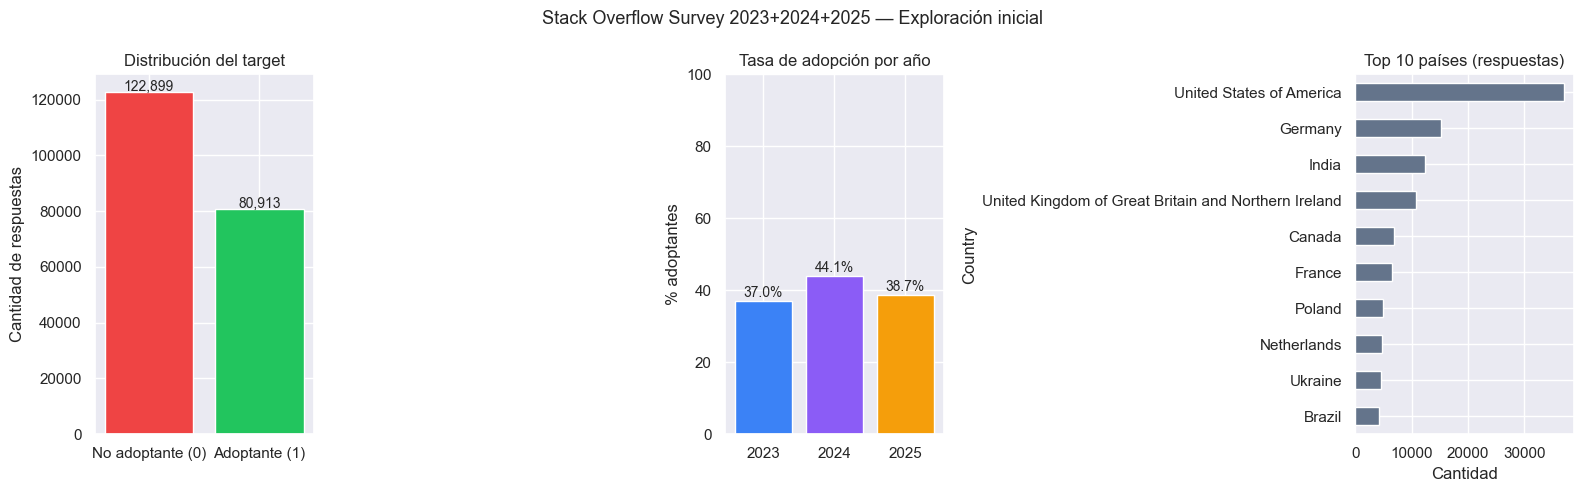

✅ Gráfico guardado en outputs/entrega1_exploracion.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Stack Overflow Survey 2023+2024+2025 — Exploración inicial', fontsize=13)

# 7a. Distribución del target
ax = axes[0]
counts = df['target'].value_counts()
ax.bar(['No adoptante (0)', 'Adoptante (1)'], counts.values, color=['#ef4444', '#22c55e'])
ax.set_title('Distribución del target')
ax.set_ylabel('Cantidad de respuestas')
for i, v in enumerate(counts.values):
    ax.text(i, v + 200, f'{v:,}', ha='center', fontsize=10)

# 7b. Tasa de adopción por año
ax = axes[1]
tasa = df.groupby('survey_year')['target'].mean() * 100
colors = ['#3b82f6', '#8b5cf6', '#f59e0b']
ax.bar(tasa.index.astype(str), tasa.values, color=colors)
ax.set_title('Tasa de adopción por año')
ax.set_ylabel('% adoptantes')
ax.set_ylim(0, 100)
for i, v in enumerate(tasa.values):
    ax.text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=10)

# 7c. Top 10 países
ax = axes[2]
df['Country'].value_counts().head(10).plot(kind='barh', ax=ax, color='#64748b')
ax.set_title('Top 10 países (respuestas)')
ax.set_xlabel('Cantidad')
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('../outputs/entrega1_exploracion.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Gráfico guardado en outputs/entrega1_exploracion.png')

## 8. Resumen final para el documento

In [10]:
print('╔══════════════════════════════════════════════════════════════╗')
print('║           RESUMEN PARA DOCUMENTO DE ENTREGA 1               ║')
print('╠══════════════════════════════════════════════════════════════╣')
print('║ Pregunta:                                                    ║')
print('║   ¿Qué características del perfil de un desarrollador        ║')
print('║   predicen su adopción sostenida de herramientas de IA?      ║')
print('║                                                              ║')
print('║ Dataset: Stack Overflow Developer Survey 2023 + 2024 + 2025  ║')
print('║ Fuente:  https://survey.stackoverflow.co/                    ║')
print('║ Licencia: Open Database License (ODbL)                       ║')
print('╠══════════════════════════════════════════════════════════════╣')
print(f'║ Filas totales:    {len(df):>10,}                               ║')
print(f'║ Adoptantes (1):   {df["target"].sum():>10,} ({df["target"].mean():.1%})                    ║')
print(f'║ No adoptantes (0):{(len(df)-df["target"].sum()):>10,} ({1-df["target"].mean():.1%})                    ║')
print('╠══════════════════════════════════════════════════════════════╣')
for year in [2023, 2024, 2025]:
    sub = df[df['survey_year'] == year]
    tasa = sub['target'].mean()
    print(f'║ {year}:  {sub.shape[0]:>6,} respuestas  |  adopción: {tasa:.1%}                ║')
print('╠══════════════════════════════════════════════════════════════╣')
print('║ === Limitaciones documentadas ===                            ║')
print('║  ⚠️  Renombramiento AIAcc↔AIBen aplicado en 2023             ║')
print('║      (diferencia de schema respecto a 2024+)                 ║')
print('║  ⚠️  Verificar AISent 2025 si tasa difiere de expectativa     ║')
print('╚══════════════════════════════════════════════════════════════╝')

# Corrección: tasa real de adopción excluyendo NaN en AISelect
print("\n=== Tasa de adopción sobre respondentes válidos (excluye NaN en AISelect) ===")
for year in [2023, 2024, 2025]:
    sub = df[df['survey_year'] == year].copy()
    sub_valido = sub[sub['AISelect'].notna()]
    n_nan = sub['AISelect'].isna().sum()
    n_total = len(sub)
    tasa_real = sub_valido['target'].mean()
    print(f"{year}: {len(sub_valido):,} válidos de {n_total:,} "
          f"({n_nan:,} NaN = {n_nan/n_total:.1%}) → adopción real: {tasa_real:.1%}")

print("\n⚠️  La tasa del 38.7% en 2025 incluye NaN como target=0.")
print("    Usar la tasa sobre válidos para comparaciones inter-año.")

╔══════════════════════════════════════════════════════════════╗
║           RESUMEN PARA DOCUMENTO DE ENTREGA 1               ║
╠══════════════════════════════════════════════════════════════╣
║ Pregunta:                                                    ║
║   ¿Qué características del perfil de un desarrollador        ║
║   predicen su adopción sostenida de herramientas de IA?      ║
║                                                              ║
║ Dataset: Stack Overflow Developer Survey 2023 + 2024 + 2025  ║
║ Fuente:  https://survey.stackoverflow.co/                    ║
║ Licencia: Open Database License (ODbL)                       ║
╠══════════════════════════════════════════════════════════════╣
║ Filas totales:       203,812                               ║
║ Adoptantes (1):       80,913 (39.7%)                    ║
║ No adoptantes (0):   122,899 (60.3%)                    ║
╠══════════════════════════════════════════════════════════════╣
║ 2023:  89,184 respuestas  |  adopció